In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d playlist/men-women-classification

Dataset URL: https://www.kaggle.com/datasets/playlist/men-women-classification
License(s): copyright-authors
100% 1.19G/1.19G [00:11<00:00, 108MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile("/content/men-women-classification.zip")
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, MaxPooling2D, BatchNormalization, Dropout, Rescaling

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Simple CNN

In [5]:
import numpy as np
import cv2

In [6]:
test_img = cv2.imread('/content/data/men/00000001.jpg')

In [7]:
import matplotlib.pyplot as plt


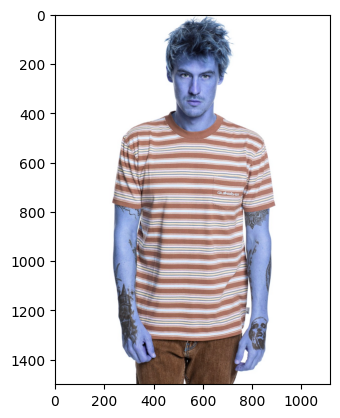

In [8]:
plt.imshow(test_img)

In [9]:
test_img.shape

(1500, 1117, 3)

In [10]:
dataset = keras.utils.image_dataset_from_directory(
    "data",
    validation_split = .2,
    image_size = (128, 128),
    batch_size = 32,
    label_mode = 'binary',
    subset = "both", # when use random validation_split
    seed = 123 # fixed splitting
)

Found 3330 files belonging to 2 classes.
Using 2664 files for training.
Using 666 files for validation.


In [11]:
train_ds, val_ds = dataset

In [12]:
# model = Sequential()

# # Input + Normalize
# model.add(Rescaling(1./255, input_shape=(128, 128, 3)))

# # 1st CNN Layer
# model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
# model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))

# # 2nd CNN Layer
# model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
# model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))

# # 3rd CNN Layer
# model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
# model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))


# # Flatten
# model.add(Flatten())

# # Fully Connected layer
# model.add(Dense(128, activation='relu'))
# model.add(Dense(64, activation='relu'))

# # Output Layer
# model.add(Dense(1, activation='sigmoid'))


In [13]:
# # Compile

# model.compile(optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy'])

In [14]:
# model.summary()

In [15]:
# # model train

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50
#     )

In [16]:
# plt.plot(history.history['loss'], color='red',label='train')
# plt.plot(history.history['val_loss'], color='blue',label='validation')

# plt.legend()
# plt.show()

In [17]:
# plt.plot(history.history['accuracy'], color='red',label='train')
# plt.plot(history.history['val_accuracy'], color='blue',label='validation')

# plt.legend()
# plt.show()

In [18]:
# test_img = cv2.imread('/content/-6mitwr.jpg')

In [19]:
# test_img

In [20]:
# plt.imshow(test_img)

In [21]:
# test_img.shape

In [22]:
# test_img = cv2.resize(test_img,(128,128))

In [23]:
# plt.imshow(test_img)

In [24]:
# for input batch
# test_input = test_img.reshape((1, 128, 128, 3))

In [25]:

# prediction = model.predict(test_input)[0][0]

In [26]:
# if prediction > 0.5:
#     print("Woman")
# else:
#     print("Man")

# **Data Augmentation**

In [27]:
data_augmentation = tf.keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1)
])

In [28]:
from tensorflow.keras.layers import *

<!-- Execution Order:
তোমার code (❌ Less Optimal):
Conv2D → ReLU apply → BatchNormalization → MaxPool → Dropout
আমার suggested code (✅ Best Practice):
Conv2D → BatchNormalization → ReLU apply → MaxPool → Dropout

কেন পার্থক্য হয়?
BatchNorm-এর কাজ হলো raw values normalize করা — mean 0, variance 1 বানানো।
পরিস্থিতিকী হয়ReLU আগে হলেReLU সব negative value 0 করে দেয়, তারপর BatchNorm একটা incomplete/skewed distribution normalize করেBatchNorm আগে হলেপুরো raw distribution normalize হয়, তারপর ReLU কাজ করে → more meaningful activation -->

Execution Order:
তোমার code (❌ Less Optimal):
Conv2D → ReLU apply → BatchNormalization → MaxPool → Dropout
আমার suggested code (✅ Best Practice):
Conv2D → BatchNormalization → ReLU apply → MaxPool → Dropout

কেন পার্থক্য হয়?
BatchNorm-এর কাজ হলো raw values normalize করা — mean 0, variance 1 বানানো।
পরিস্থিতিকী হয়ReLU আগে হলেReLU সব negative value 0 করে দেয়, তারপর BatchNorm একটা incomplete/skewed distribution normalize করেBatchNorm আগে হলেপুরো raw distribution normalize হয়, তারপর ReLU কাজ করে → more meaningful activation

# (Conv2D  -> ReLU -> BN)




---



In [29]:
model = Sequential()

# Input + Normalize
model.add(Rescaling(1./255, input_shape=(128, 128, 3)))

# Data Augmentation
model.add(RandomFlip('horizontal'))
model.add(RandomRotation(.1))
model.add(RandomZoom(.1))
model.add(RandomContrast(.1))

# 1st CNN Layer
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
# model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model.add(Dropout(.25))

# 2nd CNN Layer
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
# model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model.add(Dropout(.25))

# 3rd CNN Layer
model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
# model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model.add(Dropout(.25))


# Flatten
model.add(Flatten())

# Fully Connected layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
# model.add(Activation('relu'))
model.add(Dropout(.5))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
# model.add(Activation('relu'))
model.add(Dropout(.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
# from tensorflow.keras.callbacks import  EarlyStopping

# early_stop = EarlyStopping(
#     monitor = 'val_loss',
#     patience = 5,
#     restore_best_weights = True
# )

In [31]:
# Compile

model.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [32]:
# model train

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # callbacks=[early_stop]
    )

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 278ms/step - accuracy: 0.5589 - loss: 0.8159 - val_accuracy: 0.4204 - val_loss: 1.9592
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.5912 - loss: 0.7426 - val_accuracy: 0.4204 - val_loss: 2.1042
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.6100 - loss: 0.6992 - val_accuracy: 0.4189 - val_loss: 2.0192
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 263ms/step - accuracy: 0.6134 - loss: 0.6940 - val_accuracy: 0.5661 - val_loss: 0.6982
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 278ms/step - accuracy: 0.6254 - loss: 0.6725 - val_accuracy: 0.4204 - val_loss: 0.8490
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.6066 - loss: 0.6714 - val_accuracy: 0.6456 - val_loss: 0.6319
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.6453 - loss: 0.6517 - val_accuracy: 0.6321 - val_loss: 0.6252
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.6415 - loss: 0.6400 - val_accu

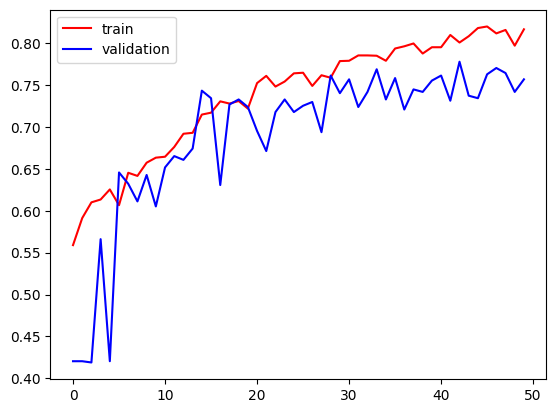

In [35]:
plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue',label='validation')

plt.legend()
plt.show()

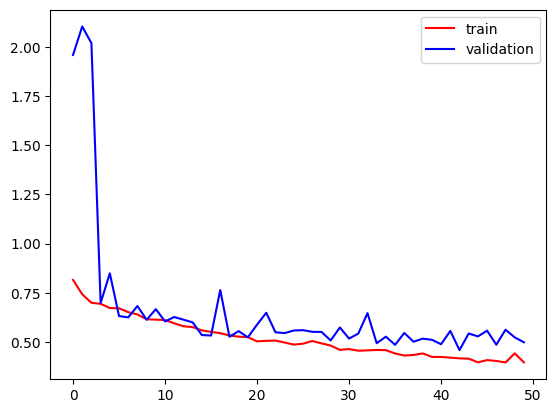

In [36]:
plt.plot(history.history['loss'], color='red',label='train')
plt.plot(history.history['val_loss'], color='blue',label='validation')

plt.legend()
plt.show()

In [37]:
model2 = Sequential()

# Input + Normalize
model2.add(Rescaling(1./255, input_shape=(128, 128, 3)))

# Data Augmentation
model2.add(RandomFlip('horizontal'))
model2.add(RandomRotation(.1))
model2.add(RandomZoom(.1))
model2.add(RandomContrast(.1))

# 1st CNN Layer
model2.add(Conv2D(32, kernel_size=(3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model2.add(Dropout(.25))

# 2nd CNN Layer
model2.add(Conv2D(64, kernel_size=(3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model2.add(Dropout(.25))

# 3rd CNN Layer
model2.add(Conv2D(128, kernel_size=(3,3), padding='same'))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(MaxPool2D(pool_size=(2,2), strides=2, padding='same'))
model2.add(Dropout(.25))


# Flatten
model2.add(Flatten())

# Fully Connected layer
model2.add(Dense(128))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(.5))

model2.add(Dense(64))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(.3))

# Output Layer
model2.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
# Compile

model2.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [39]:
# model train

history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # callbacks=[early_stop]
    )

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 272ms/step - accuracy: 0.5875 - loss: 0.7210 - val_accuracy: 0.4204 - val_loss: 0.7773
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.6235 - loss: 0.6770 - val_accuracy: 0.5360 - val_loss: 0.6989
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.6265 - loss: 0.6519 - val_accuracy: 0.4580 - val_loss: 0.7632
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.6408 - loss: 0.6406 - val_accuracy: 0.4459 - val_loss: 0.7845
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 265ms/step - accuracy: 0.6539 - loss: 0.6182 - val_accuracy: 0.5015 - val_loss: 0.7217
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 276ms/step - accuracy: 0.6787 - loss: 0.5989 - val_accuracy: 0.6952 - val_loss: 0.5795
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.6787 - loss: 0.6000 - val_accuracy: 0.6967 - val_loss: 0.5699
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.6911 - loss: 0.5893 - val_accu

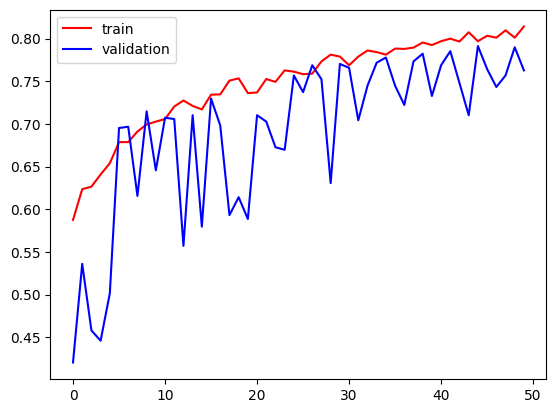

In [40]:
plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue',label='validation')

plt.legend()
plt.show()

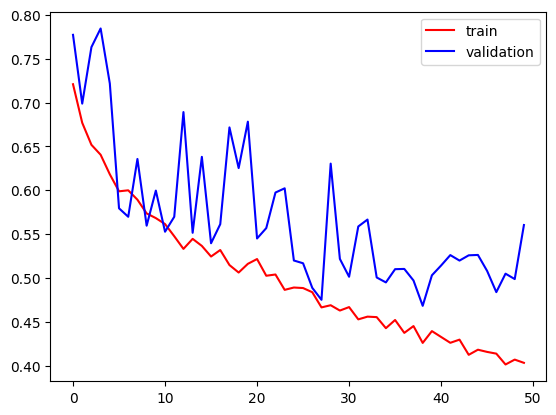

In [41]:
plt.plot(history.history['loss'], color='red',label='train')
plt.plot(history.history['val_loss'], color='blue',label='validation')

plt.legend()
plt.show()

In [42]:
model.save('model2.keras')
print("Model saved!")

Model saved!


# Training এর সময় best model automatically save করতে চাইলে:

In [34]:
# from tensorflow.keras.callbacks import ModelCheckpoint

# checkpoint = ModelCheckpoint(
#     'best_model2.keras',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50,
#     callbacks=[checkpoint]  # এখানে add করো
# )